# Fashion200k Dataset Processing Notebook

This notebook downloads the Fashion200k dataset, processes it, exports images, builds an inventory list, and generates the `inventory_seed.sql` file needed for the database.

**Instructions:**
1. Run all cells in order from top to bottom.
2. The first run will download the dataset (~2GB), which may take time.
3. Subsequent runs can skip the download by loading from the local parquet file.
4. Ensure you have enough disk space for images (~10GB).
5. After running this notebook, you can run `docker compose up` to start the services.

**Prerequisites:**
- Install required packages: `pip install datasets tqdm pillow`
- Ensure the `data/raw/fashion200k` directory exists (it will be created if not).

# Download dataset

# Fashion200k Dataset Processing Notebook

This notebook downloads the Fashion200k dataset, processes it, exports images, builds an inventory list, and generates the `inventory_seed.sql` file needed for the database.

**Instructions:**
1. Run all cells in order from top to bottom.
2. The first run will download the dataset (~2GB), which may take time.
3. Subsequent runs can skip the download by loading from the local parquet file.
4. Ensure you have enough disk space for images (~10GB).
5. After running this notebook, you can run `docker compose up` to start the services.

**Prerequisites:**
- Install required packages: `pip install datasets tqdm pillow`
- Ensure the `data/raw/fashion200k` directory exists (it will be created if not).

In [1]:
# Import necessary libraries
from datasets import load_dataset
from pathlib import Path

d:\Projects\fashion-recommender\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Check if local parquet file exists to decide whether to download or load locally
from pathlib import Path

parquet_path = Path("../data/raw/fashion200k/fashion200k.parquet")
if parquet_path.exists():
    print("Local parquet file found. You can skip the download cell and go to 'Import dataset from local path'.")
else:
    print("Local parquet file not found. Proceed with downloading the dataset.")

Local parquet file not found. Proceed with downloading the dataset.


In [3]:
# Download the Fashion200k dataset from Hugging Face
# This may take some time on first run (~2GB)
ds = load_dataset("Marqo/fashion200k", split="data")
len(ds)

201624

# Export dataset to local path

In [4]:
# Export the dataset to a local Parquet file for faster loading in future runs
output_dir = Path("../data/raw/fashion200k")
output_dir.mkdir(parents=True, exist_ok=True)

parquet_path = output_dir / "fashion200k.parquet"
ds.to_parquet(parquet_path)

parquet_path

Creating parquet from Arrow format: 100%|██████████| 36/36 [00:03<00:00,  9.18ba/s]


WindowsPath('../data/raw/fashion200k/fashion200k.parquet')

# Import dataset from local path

In [5]:
# Load the dataset from the local Parquet file (faster than re-downloading)
from datasets import load_dataset

output_dir = Path("../data/raw/fashion200k")
parquet_path = output_dir / "fashion200k.parquet"

ds_local = load_dataset(
    "parquet",
    data_files=str(parquet_path),
    split="train"
)

len(ds_local), ds_local.column_names

Generating train split: 201624 examples [00:04, 42212.59 examples/s]


(201624, ['image', 'category1', 'category2', 'category3', 'text', 'item_ID'])

In [6]:
# Check the dataset structure
ds_local.column_names
type(ds_local[0]["image"])

PIL.JpegImagePlugin.JpegImageFile

In [7]:
# Define the directory for saving images
from pathlib import Path

IMAGE_DIR = Path("../data/raw/fashion200k/images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
# Export all images from the dataset to the local directory
# This may take time and requires ~10GB disk space
from tqdm import tqdm

def export_images(dataset, out_dir):
    saved = 0
    skipped = 0

    for row in tqdm(dataset, total=len(dataset)):
        item_id = row["item_ID"]
        img = row["image"]

        out_path = out_dir / f"{item_id}.jpg"

        if out_path.exists():
            skipped += 1
            continue

        img.save(out_path, format="JPEG", quality=95)
        saved += 1

    return saved, skipped

saved, skipped = export_images(ds_local, IMAGE_DIR)
saved, skipped

100%|██████████| 201624/201624 [03:32<00:00, 946.61it/s] 


(201550, 74)

In [9]:
# Check a sample exported image
import random
from PIL import Image

sample = random.choice(list(IMAGE_DIR.iterdir()))
sample, Image.open(sample)

(WindowsPath('../data/raw/fashion200k/images/90973200_1.jpg'),
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=183x567>)

# Build inventory schema

In [10]:
# Build the inventory list from the dataset, ensuring unique item_ids
def build_inventory(dataset, image_dir):
    inventory = []
    seen_item_ids = set()

    for row in dataset:
        item_id = row["item_ID"]
        if item_id in seen_item_ids:
            continue  # Skip duplicates
        seen_item_ids.add(item_id)
        inventory.append({
            "item_id": item_id,
            "image_path": str(image_dir / f'{item_id}.jpg'),
            "category_l1": row["category1"],
            "category_l2": row["category2"],
            "category_l3": row["category3"],
            "description": row["text"],
        })

    return inventory

inventory = build_inventory(ds_local, IMAGE_DIR)
len(inventory)

201550

In [11]:
# Verify that all item_ids are unique
item_ids = [item['item_id'] for item in inventory]
unique_item_ids = set(item_ids)
print(f"Total items: {len(item_ids)}")
print(f"Unique item_ids: {len(unique_item_ids)}")
if len(item_ids) != len(unique_item_ids):
    print("Duplicates found!")
    from collections import Counter
    counts = Counter(item_ids)
    duplicates = {k: v for k, v in counts.items() if v > 1}
    print(f"Number of duplicate item_ids: {len(duplicates)}")
    print("Sample duplicates:", list(duplicates.items())[:5])

Total items: 201550
Unique item_ids: 201550


Text(0.5, 1.0, 'dresses / mini and short dresses\ngreen seamed a-line dress')

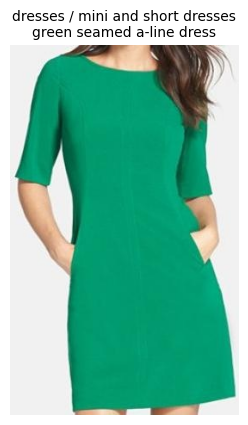

In [12]:
# Display a sample item with its image
from PIL import Image
import matplotlib.pyplot as plt

item = inventory[0]

img = Image.open(item["image_path"])

plt.imshow(img)
plt.axis("off")
plt.title(
    f'{item["category_l1"]} / {item["category_l2"]}\n{item["category_l3"]}',
    fontsize=10
)

In [13]:
# Print the details of the first item
inventory[0]

{'item_id': '51727804_0',
 'image_path': '..\\data\\raw\\fashion200k\\images\\51727804_0.jpg',
 'category_l1': 'dresses',
 'category_l2': 'mini and short dresses',
 'category_l3': 'green seamed a-line dress',
 'description': 'green dress. the dress is made of a shiny material and has a boat neckline. it is a short dress with a straight cut and is worn by a woman.'}

In [14]:
# Generate the inventory_seed.sql file for database seeding
from pathlib import Path
import sqlparse

output_sql = Path("../data/processed/inventory_seed.sql")

def sql_escape(s):
    if s is None:
        return "NULL"
    return "'" + s.replace("'", "''") + "'"

lines = []
lines.append("BEGIN;")
lines.append("TRUNCATE TABLE items;")

for item in inventory:
    line = f"""
    INSERT INTO items (item_id, image_path, category_l1, category_l2, category_l3, description)
    VALUES (
        {sql_escape(item["item_id"])},
        {sql_escape(item["image_path"])},
        {sql_escape(item["category_l1"])},
        {sql_escape(item["category_l2"])},
        {sql_escape(item["category_l3"])},
        {sql_escape(item["description"])}
    );
    """
    lines.append(line)

lines.append("COMMIT;")

sql_text = "\n".join(lines)
output_sql.write_text(sql_text, encoding="utf-8")

output_sql, len(inventory)

(WindowsPath('../data/processed/inventory_seed.sql'), 201550)

## Next Steps

Now that the `inventory_seed.sql` file has been generated with unique items, you can proceed to set up the database:

1. Ensure the `data/processed/inventory_seed.sql` file exists and is not empty.
2. Run `docker compose up --build` to start the services.
3. The database will be seeded automatically with the inventory data.
4. You can then query the items table to verify the data is loaded.

If you encounter any issues, check the Docker logs with `docker compose logs postgres`.